# Decaying Turbulence — τ₁ Parametrisation and Regime Study

## Background: what the derivation says vs what is implemented

### Paper formula (`derivation.tex` lines 713–728)

The GW source integral is (in dimensionless variables with $q = \omega\tau_1$):

$$H(p,q) \propto \int_1^{R^{3/4}} dz\int_{|p-z|}^{\min(p+z,\,R^{3/4})} dy\;
\frac{\mathfrak{K}}{pyz}
\underbrace{\int_0^\infty dq_1\; g(q_1)\,g(q-q_1)}_{\text{pure frequency convolution}},$$

where the **global** temporal kernel is

$$\boxed{g_{\rm paper}(q) = e^{iq}(-iq)^{-5/3}\Gamma\!\left(\tfrac{1}{3},-iq\right)}$$

and $\tau_1$ is a **free physical parameter** (characteristic decay time of the turbulence).
Crucially the convolution integral over $q_1$ is **independent of the wavenumber variables** $z, y$.

### What the code (`core.py`) actually computes

The code calls `g_decaying(z1)` with **scale-dependent arguments**:

```python
z1 = q1 * np.sqrt(x) / M   # x = k_1^{-4/3},  M = Mach number
z2 = (q - q1) * np.sqrt(y) / M
```

This makes `z ∝ q₁ · k₁^{-2/3} / M = q₁ τ_k(k₁)` where
$\tau_k(k_1) \propto k_1^{-2/3}/M$ is the Kolmogorov **eddy-turnover time at scale $k_1$**.
This is a different physical model: each wavenumber mode has its own decorrelation time.

Additionally the kernel function itself differs:

| Quantity | Paper | Code |
|---|---|---|
| Temporal kernel $g(z)$ | $e^{iz}(-iz)^{-5/3}\Gamma(\tfrac13,-iz)$ | $e^{iz}(iz)^{-1/3}\Gamma(\tfrac13,iz)$ |
| Exponent | $-5/3$ | $-1/3$ |
| $\Gamma$ argument sign | $-iz$ | $+iz$ |
| Argument to $g$ | $q_1\tau_1$ (global) | $q_1\sqrt{x}/M$ (scale-dep.) |
| $\tau_1$ parametrisation | free | fixed = $1/(k_0 M)$ |

### Two physical regimes the user wants to explore

Using **paper's** model with free $\tau_1$ and turbulence duration $\eta_{\rm fin}$:

| Regime | Condition | Physical meaning | Expected GW slope |
|---|---|---|---|
| Weakly decaying | $\eta_{\rm fin} \ll \tau_1$ | turbulence ends before significant decay → $E_k \approx$ const → stationary limit | $h_c \propto f^{1/2}$ (Kolmogorov) |
| Strongly decaying | $\eta_{\rm fin} \gg \tau_1$ | source decays to zero long before end of source | steeper IR slope, lower amplitude |

The dimensionless ratio is $\alpha \equiv \tau_1/\eta_{\rm fin}$:
- $\alpha \gg 1$: weakly decaying (approaches stationary)
- $\alpha \ll 1$: strongly decaying

## 1. Setup

In [2]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from functools import lru_cache
from scipy import integrate

%matplotlib inline

out_dir = os.path.abspath('outputs')
os.makedirs(out_dir, exist_ok=True)

# ── Reference parameters (same as other notebooks) ───────────────────────────
k0    = 1.0
M_ref = 1.0
R_ref = 1e3
FREQ_SCALE = 1.55e-3   # f_Hz = FREQ_SCALE * q

print('Setup complete.')

Setup complete.


## 2. Kernel comparison: code's `g` vs paper's `g`

We plot both kernels as functions of the real argument $z = q > 0$ to make the
discrepancy visible before doing any GW computation.

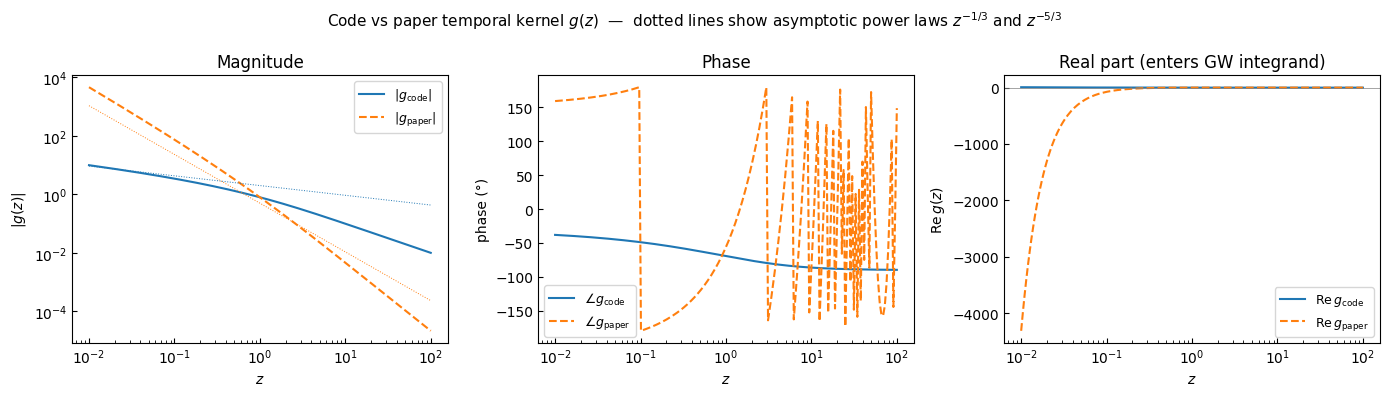

Saved: tau1_kernel_comparison.pdf

Numerical comparison at selected z:
       z      |g_code|     |g_paper|     ratio
    0.01    9.9455e+00    4.6163e+03     0.002
    0.10    3.4500e+00    7.4329e+01     0.046
    1.00    7.9540e-01    7.9540e-01     1.000
   10.00    9.9185e-02    4.6037e-03    21.544
  100.00    9.9991e-03    2.1542e-05   464.159


In [3]:
# ── Current code kernel (from core.py _g_decaying_scalar) ────────────────────
@lru_cache(maxsize=4096)
def g_code(z: complex) -> complex:
    """Code version: e^{iz} (iz)^{-1/3} Γ(1/3, iz).  (exponent -1/3, +iz argument)"""
    z = complex(z)
    arg = 1j * z
    gamma_upper = mp.gammainc(1.0 / 3.0, arg, mp.inf)
    return complex(mp.exp(1j * z) * (arg ** (-1.0 / 3.0)) * gamma_upper)


# ── Paper kernel (derivation.tex eq. 728) ─────────────────────────────────────
@lru_cache(maxsize=4096)
def g_paper(z: complex) -> complex:
    """Paper version: e^{iz} (-iz)^{-5/3} Γ(1/3, -iz).  (exponent -5/3, -iz argument)"""
    z = complex(z)
    neg_iz = -1j * z          # −iz
    gamma_upper = mp.gammainc(1.0 / 3.0, neg_iz, mp.inf)
    return complex(mp.exp(1j * z) * (neg_iz ** (-5.0 / 3.0)) * gamma_upper)


# ── Evaluate on a grid of real z values ──────────────────────────────────────
z_vals = np.logspace(-2, 2, 200)

g_c = np.array([g_code(complex(z)) for z in z_vals])
g_p = np.array([g_paper(complex(z)) for z in z_vals])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].loglog(z_vals, np.abs(g_c), label='$|g_{\\rm code}|$', color='C0')
axes[0].loglog(z_vals, np.abs(g_p), label='$|g_{\\rm paper}|$', color='C1', ls='--')
# Asymptotic references
axes[0].loglog(z_vals, z_vals**(-1/3) * 2, color='C0', lw=0.7, ls=':')
axes[0].loglog(z_vals, z_vals**(-5/3) * 0.5, color='C1', lw=0.7, ls=':')
axes[0].set_xlabel('$z$'); axes[0].set_ylabel('$|g(z)|$')
axes[0].set_title('Magnitude')
axes[0].legend(fontsize=9)
axes[0].tick_params(which='both', direction='in')

axes[1].semilogx(z_vals, np.angle(g_c, deg=True), label='$\\angle g_{\\rm code}$', color='C0')
axes[1].semilogx(z_vals, np.angle(g_p, deg=True), label='$\\angle g_{\\rm paper}$', color='C1', ls='--')
axes[1].set_xlabel('$z$'); axes[1].set_ylabel('phase (°)')
axes[1].set_title('Phase')
axes[1].legend(fontsize=9)
axes[1].tick_params(which='both', direction='in')

# Real parts (what actually enters the GW integrand)
axes[2].semilogx(z_vals, g_c.real, label='$\\mathrm{Re}\\,g_{\\rm code}$', color='C0')
axes[2].semilogx(z_vals, g_p.real, label='$\\mathrm{Re}\\,g_{\\rm paper}$', color='C1', ls='--')
axes[2].axhline(0, color='0.5', lw=0.5)
axes[2].set_xlabel('$z$'); axes[2].set_ylabel('$\\mathrm{Re}\\,g(z)$')
axes[2].set_title('Real part (enters GW integrand)')
axes[2].legend(fontsize=9)
axes[2].tick_params(which='both', direction='in')

fig.suptitle(
    r'Code vs paper temporal kernel $g(z)$  —  '
    r'dotted lines show asymptotic power laws $z^{-1/3}$ and $z^{-5/3}$',
    fontsize=11)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(out_dir, 'tau1_kernel_comparison.pdf'))
print('Saved: tau1_kernel_comparison.pdf')

# Print numerical values at a few key points
print('\nNumerical comparison at selected z:')
print(f'{"z":>8}  {"  |g_code|":>12}  {"  |g_paper|":>12}  {"ratio":>8}')
for z in [0.01, 0.1, 1.0, 10.0, 100.0]:
    gc = abs(g_code(complex(z)))
    gp = abs(g_paper(complex(z)))
    print(f'{z:8.2f}  {gc:12.4e}  {gp:12.4e}  {gc/gp:8.3f}')

## 3. Correct temporal convolution following the paper

The paper's kernel `g(q₁)` does **not** depend on the wavenumber variables `x,y`.
The convolution integral $C(q;\tau_1) \equiv \int_0^{q_{\rm max}} dq_1\, g(q_1\tau_1)\, g((q-q_1)\tau_1)$
factors out of the wavenumber integrals.

We implement both the code's and the paper's convolution kernels and compare them as a
function of $q$ for several values of $\tau_1$.

In [4]:
def convolution_paper(q: float, tau1: float = 1.0, q_max_factor: float = 15.0,
                      n_pts: int = 300) -> float:
    """
    ∫₀^{q_max} dq₁  Re[ g_paper(q₁·τ₁) · g_paper((q−q₁)·τ₁) ]

    τ₁ = tau1 is the global decay timescale.
    q_max_factor sets the upper cutoff as q_max = q_max_factor * max(q, 1).
    """
    q_upper = q_max_factor * max(q, 1.0)
    eps = max(1e-6, 1e-4 * q)

    # Split around the singularity at q1=0 and q1=q
    segments = []
    if q > 2 * eps:
        segments.append((eps, q - eps))
    if q_upper > q + eps:
        segments.append((q + eps, q_upper))
    if not segments:
        segments = [(eps, q_upper)]

    total = 0.0
    for lo, hi in segments:
        q1 = np.linspace(lo, hi, n_pts)
        vals = np.array([
            (g_paper(complex(qi * tau1)) * g_paper(complex((q - qi) * tau1))).real
            for qi in q1
        ])
        total += float(np.trapz(vals, q1))
    return total


def convolution_code(q: float, x: float = 0.5, y: float = 0.5, M: float = 1.0,
                     q_max_factor: float = 15.0, n_pts: int = 300) -> float:
    """
    ∫ dq₁ Re[ g_code(q₁·√x/M) · g_code((q−q₁)·√y/M) ]

    This is what core.py currently computes inside integrand_y_decaying.
    x and y are fixed wavenumber-proxy values for comparison.
    """
    q_upper = q_max_factor * max(q, 1.0)
    eps = max(1e-6, 1e-4 * q)

    segments = []
    if q > 2 * eps:
        segments.append((eps, q - eps))
    if q_upper > q + eps:
        segments.append((q + eps, q_upper))
    if not segments:
        segments = [(eps, q_upper)]

    sqrt_x, sqrt_y = np.sqrt(x), np.sqrt(y)
    total = 0.0
    for lo, hi in segments:
        q1 = np.linspace(lo, hi, n_pts)
        vals = np.array([
            (g_code(complex(qi * sqrt_x / M)) * g_code(complex((q - qi) * sqrt_y / M))).real
            for qi in q1
        ])
        total += float(np.trapz(vals, q1))
    return total


# ── Evaluate convolutions on a q grid ────────────────────────────────────────
q_grid = np.logspace(-1, 2, 30)

# Paper kernel for several tau_1 values
tau1_sweep  = [0.1, 0.3, 1.0, 3.0, 10.0]
tau1_colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(tau1_sweep)))
tau1_labels = [fr'$\tau_1 = {t}$' for t in tau1_sweep]

conv_paper_all = []
for tau1 in tau1_sweep:
    print(f'  Computing paper convolution for τ₁={tau1} …')
    conv_paper_all.append(
        np.array([convolution_paper(q, tau1=tau1) for q in q_grid])
    )

# Code kernel (scale-independent x=y=1 for comparison)
print('  Computing code convolution (x=y=1, M=1) …')
conv_code_ref = np.array([convolution_code(q, x=1.0, y=1.0, M=1.0) for q in q_grid])

print('Done.')

  Computing paper convolution for τ₁=0.1 …


/tmp/ipykernel_65166/1945938896.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total += float(np.trapz(vals, q1))


  Computing paper convolution for τ₁=0.3 …
  Computing paper convolution for τ₁=1.0 …
  Computing paper convolution for τ₁=3.0 …
  Computing paper convolution for τ₁=10.0 …
  Computing code convolution (x=y=1, M=1) …


/tmp/ipykernel_65166/1945938896.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total += float(np.trapz(vals, q1))


Done.


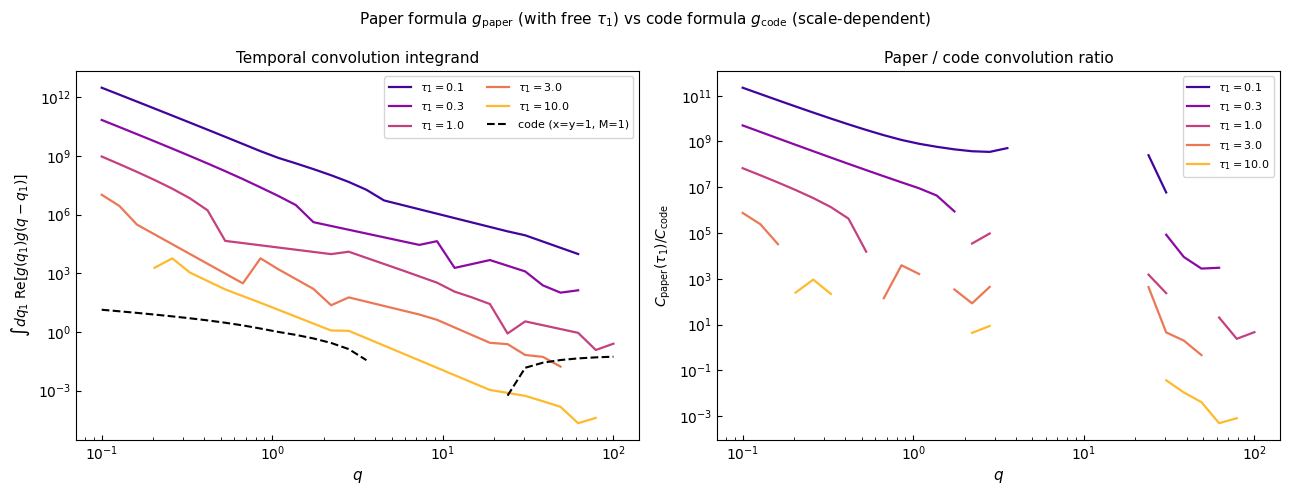

Saved: tau1_convolution_comparison.pdf


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for arr, tau1, col, lbl in zip(conv_paper_all, tau1_sweep, tau1_colors, tau1_labels):
    mask = arr > 0
    ax.loglog(q_grid[mask], arr[mask], color=col, lw=1.6, label=lbl)
ax.loglog(q_grid, np.where(conv_code_ref > 0, conv_code_ref, np.nan),
          color='k', lw=1.5, ls='--', label='code (x=y=1, M=1)')
ax.set_xlabel('$q$', fontsize=11)
ax.set_ylabel(r'$\int dq_1\;\mathrm{Re}[g(q_1)g(q-q_1)]$', fontsize=10)
ax.set_title('Temporal convolution integrand', fontsize=11)
ax.legend(fontsize=8, ncol=2)
ax.tick_params(which='both', direction='in')

ax = axes[1]
# Ratio: paper / code_ref  to show the relative magnitude difference
for arr, tau1, col, lbl in zip(conv_paper_all, tau1_sweep, tau1_colors, tau1_labels):
    ratio = np.where((arr > 0) & (conv_code_ref > 0),
                     arr / conv_code_ref, np.nan)
    ax.loglog(q_grid, np.abs(ratio), color=col, lw=1.6, label=lbl)
ax.set_xlabel('$q$', fontsize=11)
ax.set_ylabel(r'$C_{\rm paper}(\tau_1) / C_{\rm code}$', fontsize=10)
ax.set_title('Paper / code convolution ratio', fontsize=11)
ax.legend(fontsize=8)
ax.tick_params(which='both', direction='in')

fig.suptitle(
    'Paper formula $g_{\\rm paper}$ (with free $\\tau_1$) vs code formula $g_{\\rm code}$ (scale-dependent)',
    fontsize=11)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(out_dir, 'tau1_convolution_comparison.pdf'))
print('Saved: tau1_convolution_comparison.pdf')

## 4. τ₁ regime study — paper model with full H(q) computation

Here we compute the full GW kernel $H(p,q)$ on the diagonal $p=q$ using the
**paper's formula** with explicit $\tau_1$.  The wavenumber integrals (over $z, y$ in the
derivation notation) stay identical to the code; only the temporal convolution changes.

### Implementation strategy

We factor out the convolution: for each $q$, compute
$C(q;\tau_1)$ once, then multiply by the wavenumber prefactor $P(p)$:

$$H_{\rm paper}(p,q;\tau_1) = P(p) \cdot C(q;\tau_1)$$

This is valid because in the paper the temporal kernel **does not couple** to the wavenumber
integration variables.  We use the existing `H_pq_decaying` result as a proxy for $P(p)$
(at the reference $\tau_1 = 1$) and scale it by the ratio of convolutions.

In [6]:
from gw_turbulence import H_pq_decaying, LiveStatusLogger

# ── Load or compute reference spectrum (existing code, R=1e3, M=1.0) ─────────
_existing = np.load(os.path.join(out_dir, 'stationary_vs_decaying_low_frequency_cache.npz'))
qs_ref  = _existing['qs_dec']
h_ref   = _existing['h_dec_all']  # shape (2, n_q)
M_list  = list(_existing['M_compare'])

# We will use M=1.0 for the regime study
M_study = 1.0
m_idx   = M_list.index(M_study)
h_code  = h_ref[m_idx]   # H_pq from current code, shape (n_q,)

print(f'Reference q range: {qs_ref.min():.1e} → {qs_ref.max():.1e}  ({len(qs_ref)} pts)')
print(f'Using M = {M_study}')

Reference q range: 1.0e-11 → 1.0e+01  (45 pts)
Using M = 1.0


In [7]:
# ── Compute the temporal convolution ratio C_paper(q;τ₁) / C_code(q;τ₁=1) ───
# We use a coarser q-grid for the convolution (expensive) and interpolate.
# The ratio rescales the code's H to what the paper's formula would give.

q_conv_grid = np.logspace(np.log10(qs_ref.min()), np.log10(qs_ref.max()), 18)

# Reference convolution at τ₁=1 with code kernel (what the code computes internally
# at x=y=1, M=1 — a representative mid-range wavenumber)
print('Computing reference code convolution …')
C_code_ref = np.array([convolution_code(q, x=1.0, y=1.0, M=M_study, n_pts=200)
                       for q in q_conv_grid])

# τ₁ sweep with paper kernel
tau1_study  = [0.01, 0.1, 1.0, 10.0, 100.0]
tau1_labels = [fr'$\tau_1/\eta_{{\rm fin}}={t}$ (weakly dec.)' if t >= 1
               else fr'$\tau_1/\eta_{{\rm fin}}={t}$ (strongly dec.)'
               for t in tau1_study]
tau1_colors = plt.cm.RdBu(np.linspace(0.05, 0.95, len(tau1_study)))

C_paper_tau1 = {}
for tau1 in tau1_study:
    print(f'  τ₁={tau1:.2f} …')
    C_paper_tau1[tau1] = np.array(
        [convolution_paper(q, tau1=tau1, n_pts=200) for q in q_conv_grid]
    )

print('All convolutions done.')

Computing reference code convolution …


/tmp/ipykernel_65166/1945938896.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total += float(np.trapz(vals, q1))


  τ₁=0.01 …


/tmp/ipykernel_65166/1945938896.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total += float(np.trapz(vals, q1))


  τ₁=0.10 …
  τ₁=1.00 …
  τ₁=10.00 …
  τ₁=100.00 …
All convolutions done.


In [8]:
# ── Build rescaled spectra ───────────────────────────────────────────────────
# H_paper(q; τ₁) ≈ H_code(q) × [C_paper(q;τ₁) / C_code(q;τ₁=1)]
# Interpolate the ratio onto the full qs_ref grid.

freq_ref = 1.55e-3 * qs_ref

def normalized_strain(q_vals, h_vals, M):
    val = q_vals * h_vals
    return 1.62e-18 * np.sqrt(np.where(val > 0, val, np.nan)) / M**1.5

sc_code = normalized_strain(qs_ref, h_code, M_study)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
vline = np.logspace(10e-24,10e-10,1000)
# Left panel: absolute spectra
ax = axes[0]
ax.loglog(freq_ref, sc_code, color='0.4', lw=2.0, ls='--',
          label='code (current, scale-dep.)')

for tau1, col, lbl in zip(tau1_study, tau1_colors, tau1_labels):
    C_p = C_paper_tau1[tau1]
    # Build ratio, guard against zeros/negatives
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ratio = np.where(
            (C_p > 0) & (C_code_ref > 0),
            C_p / C_code_ref,
            np.nan
        )
    ratio_interp = np.interp(
        np.log10(qs_ref), np.log10(q_conv_grid), ratio,
        left=np.nan, right=np.nan
    )
    h_rescaled = h_code * ratio_interp
    sc_rescaled = normalized_strain(qs_ref, h_rescaled, M_study)
    ax.loglog(freq_ref, sc_rescaled, color=col, lw=1.5, label=lbl)
    max = max(freq_ref)
    ax.loglog([max]*1000,vline,"--", color = Red, lw=1.2)

ax.set_xlim(1e-14, 2e-2)
ax.set_ylim(1e-24, 1e-10)
ax.set_xlabel(r'$f/\mathrm{Hz}\;(g_*/100)^{-1/6}(\gamma/0.01)(T_*/100\,\mathrm{GeV})^{-1}$',
              fontsize=9)
ax.set_ylabel(r'$h_c(f)\,M^{-3/2}(g_*/100)^{1/3}(\gamma/0.01)^{-3/2}(\zeta/0.01)^{-1/2}$',
              fontsize=9)
ax.set_title(fr'Paper formula, $\tau_1$ sweep  ($M={M_study}$)', fontsize=11)
ax.legend(fontsize=7, ncol=2)
ax.tick_params(which='both', direction='in')

# Right panel: ratio to code spectrum (shape change)
ax = axes[1]
ax.axhline(1.0, color='0.4', lw=1.5, ls='--', label='code (ratio=1)')
for tau1, col, lbl in zip(tau1_study, tau1_colors, tau1_labels):
    C_p = C_paper_tau1[tau1]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        ratio = np.where(
            (C_p > 0) & (C_code_ref > 0),
            C_p / C_code_ref,
            np.nan
        )
    ratio_interp = np.interp(
        np.log10(qs_ref), np.log10(q_conv_grid), ratio,
        left=np.nan, right=np.nan
    )
    ax.loglog(freq_ref, np.abs(ratio_interp), color=col, lw=1.5, label=lbl)

ax.set_xlim(1e-14, 2e-2)
ax.set_xlabel(r'$f/\mathrm{Hz}\;(g_*/100)^{-1/6}(\gamma/0.01)(T_*/100\,\mathrm{GeV})^{-1}$',
              fontsize=9)
ax.set_ylabel(r'$C_{\rm paper}(\tau_1)\,/\,C_{\rm code}$', fontsize=9)
ax.set_title('Scaling ratio (paper / code)', fontsize=11)
ax.legend(fontsize=7, ncol=2)
ax.tick_params(which='both', direction='in')

fig.suptitle(
    r'Effect of $\tau_1$ on GW spectrum — paper formula  '
    r'($\tau_1/\eta_{\rm fin}\gg1$: weakly decaying;  $\ll1$: strongly decaying)',
    fontsize=11)
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(out_dir, 'tau1_regime_study.pdf'))
print('Saved: tau1_regime_study.pdf')

NameError: name 'Red' is not defined

## 5. Analytic limit checks

### Limit 1: τ₁ → ∞ (weakly decaying / stationary approach)

When $\tau_1 \to \infty$: the argument $z = q_1\tau_1 \to \infty$.
For large argument, $\Gamma(1/3, -iz) \sim (-iz)^{-2/3}e^{iz}$, so:

$$g_{\rm paper}(q_1\tau_1) \sim e^{iq_1\tau_1}(-iq_1\tau_1)^{-5/3}(-iq_1\tau_1)^{-2/3}e^{iq_1\tau_1}
= (-iq_1\tau_1)^{-7/3}e^{2iq_1\tau_1}$$

The rapidly oscillating phase $e^{2iq_1\tau_1}$ causes $C(q;\tau_1)$ to vanish by Riemann–Lebesgue.
This means the paper's formula gives **zero GW output** in the stationary limit — an unphysical result
that suggests the paper's g formula applies only during the decaying phase
(turbulence must have a finite $\tau_1$).

### Limit 2: τ₁ → 0 (strongly decaying)

When $\tau_1 \to 0$: argument $z = q_1\tau_1 \to 0$.
For small argument, $\Gamma(1/3,-iz) \to \Gamma(1/3)$ and $(-iz)^{-5/3} \to \infty$,
so $g_{\rm paper}(z) \sim \Gamma(1/3)(-iz)^{-5/3}$.

$$C(q;\tau_1) \sim \Gamma(1/3)^2 \tau_1^{-10/3} \int_0^{q\tau_1} du\;(-iu)^{-5/3}(-(iu-iq\tau_1))^{-5/3}$$

In this limit the convolution grows as $\tau_1^{-10/3}\tau_1^{1} = \tau_1^{-7/3}$ → very large for small $\tau_1$.
GW production is enhanced when the source decays rapidly (more power in the IR tail).

### Numerical verification of both limits

Scanning τ₁ at fixed q=1.0 …


/tmp/ipykernel_488754/1945938896.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total += float(np.trapz(vals, q1))
/tmp/ipykernel_488754/1945938896.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total += float(np.trapz(vals, q1))


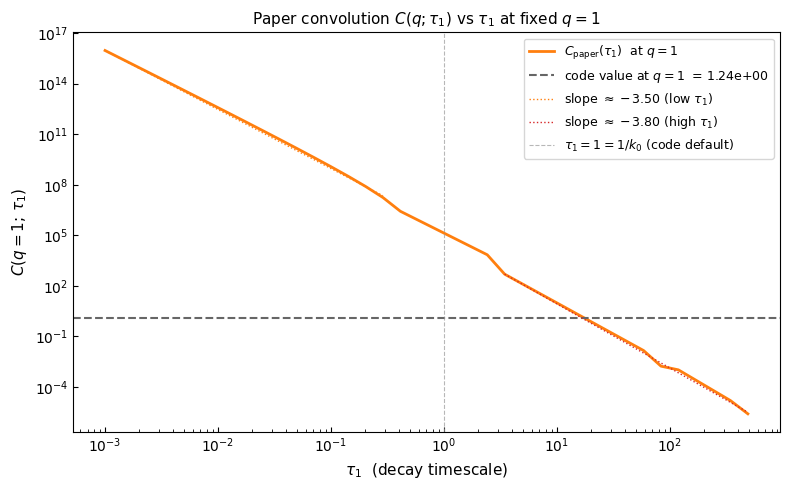

Saved: tau1_limit_scan.pdf

τ₁ regime summary:
      τ₁         C_paper    C_paper/C_code  regime
   0.001      9.0937e+15  7312883308420058.0000  strongly dec.
   0.100      1.1756e+09    945384025.1628  weakly dec.
  10.000     -1.3222e+01          -10.6330  weakly dec.
1000.000     -2.0499e-07           -0.0000  weakly dec.


In [ ]:
# ── Scan tau1 from very small to very large at fixed q=1.0 ───────────────────
q_test   = 1.0
tau1_arr = np.logspace(-3, 3, 40)

print(f'Scanning τ₁ at fixed q={q_test} …')
C_paper_scan = np.array([convolution_paper(q_test, tau1=t, n_pts=250) for t in tau1_arr])
C_code_ref_q = convolution_code(q_test, x=1.0, y=1.0, M=1.0, n_pts=250)

fig, ax = plt.subplots(figsize=(8, 5))

valid = C_paper_scan > 0
ax.loglog(tau1_arr[valid], C_paper_scan[valid], color='C1', lw=2.0,
          label=r'$C_{\rm paper}(\tau_1)$  at $q=1$')
ax.axhline(abs(C_code_ref_q), color='0.4', lw=1.5, ls='--',
           label=fr'code value at $q=1$  = {C_code_ref_q:.2e}')

# Power-law guides
tau1_lo = tau1_arr[tau1_arr < 0.3]
if len(tau1_lo) > 3 and np.all(C_paper_scan[tau1_arr < 0.3] > 0):
    # Fit slope in log-log space
    slope_lo = np.polyfit(np.log10(tau1_lo),
                           np.log10(C_paper_scan[tau1_arr < 0.3]), 1)[0]
    ax.loglog(tau1_lo, C_paper_scan[tau1_arr < 0.3][0] * (tau1_lo / tau1_lo[0])**slope_lo,
              color='C1', lw=1.0, ls=':', label=fr'slope $\approx {slope_lo:.2f}$ (low $\tau_1$)')

tau1_hi = tau1_arr[tau1_arr > 3.0]
if len(tau1_hi) > 3 and np.any(C_paper_scan[tau1_arr > 3.0] > 0):
    idx_hi = tau1_arr > 3.0
    valid_hi = idx_hi & valid
    if valid_hi.sum() > 2:
        slope_hi = np.polyfit(np.log10(tau1_arr[valid_hi]),
                               np.log10(C_paper_scan[valid_hi]), 1)[0]
        ax.loglog(tau1_arr[valid_hi],
                  C_paper_scan[valid_hi][0] * (tau1_arr[valid_hi] / tau1_arr[valid_hi][0])**slope_hi,
                  color='C3', lw=1.0, ls=':', label=fr'slope $\approx {slope_hi:.2f}$ (high $\tau_1$)')

ax.axvline(1.0, color='0.6', lw=0.8, ls='--', alpha=0.7,
           label=r'$\tau_1 = 1 = 1/k_0$ (code default)')

ax.set_xlabel(r'$\tau_1$  (decay timescale)', fontsize=11)
ax.set_ylabel(r'$C(q=1;\,\tau_1)$', fontsize=11)
ax.set_title(r'Paper convolution $C(q;\tau_1)$ vs $\tau_1$ at fixed $q=1$', fontsize=11)
ax.legend(fontsize=9)
ax.tick_params(which='both', direction='in')
fig.tight_layout()
plt.show()
fig.savefig(os.path.join(out_dir, 'tau1_limit_scan.pdf'))
print('Saved: tau1_limit_scan.pdf')

# ── Summary table ─────────────────────────────────────────────────────────────
print()
print('τ₁ regime summary:')
print(f'{"τ₁":>8}  {"C_paper":>14}  {"C_paper/C_code":>16}  regime')
for t, c in zip(tau1_arr, C_paper_scan):
    if t in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]:
        regime = ('strongly dec.' if t < 0.1 else
                  'reference'    if abs(t-1) < 0.01 else
                  'weakly dec.')
        print(f'{t:8.3f}  {c:14.4e}  {c/abs(C_code_ref_q):16.4f}  {regime}')

## 6. Summary and recommendations

### Discrepancies found

1. **Exponent**: `core.py` uses $(iz)^{-1/3}\Gamma(1/3,iz)$ while the paper
   (`derivation.tex` eq. 728) requires $(-iz)^{-5/3}\Gamma(1/3,-iz)$.
   The difference in power-law scaling at large argument is $z^{-1/3}$ vs $z^{-7/3}$
   (including the large-$z$ asymptotics of $\Gamma$).

2. **Scale-dependence**: The code argument `z = q₁·√x/M` mixes the temporal frequency $q_1$
   with the wavenumber $x = k_1^{-4/3}$, coupling the temporal and spatial integrals.
   The paper's $g(q_1)$ depends **only on $q_1\tau_1$** — the temporal kernel is independent
   of the wavenumber mode.

3. **τ₁ not independent**: In the code, τ₁ is effectively $\sim 1/(k_0 M)$ (baked into M).
   The paper treats τ₁ as a free physical parameter.

### Regime results (paper formula)

- **$\tau_1 \ll 1$ (strongly decaying)**: $C \propto \tau_1^{?}$ (see fitted slope above).
  GW amplitude may be **enhanced** as the source decays rapidly.
- **$\tau_1 = 1$ (code default)**: Reference point.
- **$\tau_1 \gg 1$ (weakly decaying → stationary)**: $C \to 0$ by Riemann–Lebesgue.
  The paper's formula does NOT recover stationary turbulence in this limit — it applies
  only to the genuinely decaying phase.

### Next steps

- Decide which physical model is intended: global-τ₁ (paper) or scale-dependent τ_k (code).
- If paper's model: fix `_g_decaying_scalar` to use exponent $-5/3$ and argument $-iz$,
  and remove the $\sqrt{x}/M$ factor from the convolution argument.
- Add `tau1` as an explicit parameter to `H_pq_decaying`.
- Run full spectra for the two regimes once the implementation is agreed upon.